Relearning pytorch because I lost the muscle memory I once had

In [8]:
import torch
import sys
device = "cuda" if torch.cuda.is_available else "cpu"

In [9]:
scalar = torch.tensor(7)
scalar

tensor(7)

In [10]:
scalar.ndim

0

In [12]:
scalar.item() # turns to a python integer

7

In [20]:
vector = torch.tensor([[7, 7]])
type(vector), vector

(torch.Tensor, tensor([[7, 7]]))

In [26]:
vector.ndim
print(vector.shape)

vector = vector.unsqueeze(1)

torch.Size([1, 1, 2])


In [28]:
vector.shape

torch.Size([1, 1, 1, 2])

In [31]:
random_tensor = torch.rand(size=(224, 224, 3))
random_tensor.shape, random_tensor.ndim

(torch.Size([224, 224, 3]), 3)

In [32]:
zeros = torch.zeros(size=(3, 4))
zeros, zeros.dtype

(tensor([[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]),
 torch.float32)

In [33]:
ones = torch.ones(size=(3, 4))

In [34]:
tensor = torch.tensor([1, 2, 3])
tensor2 = torch.tensor([3, 4, 5])

tensor * tensor2

tensor([ 3,  8, 15])

In [43]:
rand1 = torch.rand(3,3)
rand2 = torch.rand(3,3)

matrix1 = torch.tensor([[1,2,3],
                        [4,5,6],
                        [7,8,9]])
matrix2 = torch.tensor([[10,11],
                        [13,14],
                        [16,17 ]])

print(f"rand1: \n{rand1}\nrand2: {rand2}")

multiplied = torch.matmul(matrix1, matrix2)

print(f"multiplied: \n{multiplied}")

rand1: 
tensor([[0.2662, 0.8417, 0.2267],
        [0.3702, 0.9186, 0.7707],
        [0.6163, 0.1827, 0.1688]])
rand2: tensor([[0.9508, 0.6438, 0.0934],
        [0.8091, 0.9182, 0.0232],
        [0.1471, 0.1788, 0.2399]])
multiplied: 
tensor([[ 84,  90],
        [201, 216],
        [318, 342]])


In [46]:
print(f"matrix2 before transpose: {matrix2}")
matrix2_T = matrix2.T
print(f"matrix2 after transpose: {matrix2_T}")

matrix2 before transpose: tensor([[10, 11],
        [13, 14],
        [16, 17]])
matrix2 after transpose: tensor([[10, 13, 16],
        [11, 14, 17]])


In [49]:
x = torch.arange(0, 100, 10)

print(f"min: {x.min()}")
print(f"max: {x.max()}")
print(f"mean: {x.type(torch.float32).mean()}")
print(f"sum: {x.sum()}")

print(f"matrix2_H: {matrix2.H}")

min: 0
max: 90
mean: 45.0
sum: 450
matrix2_H: tensor([[10, 13, 16],
        [11, 14, 17]])


In [50]:
# Preparing data
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [51]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

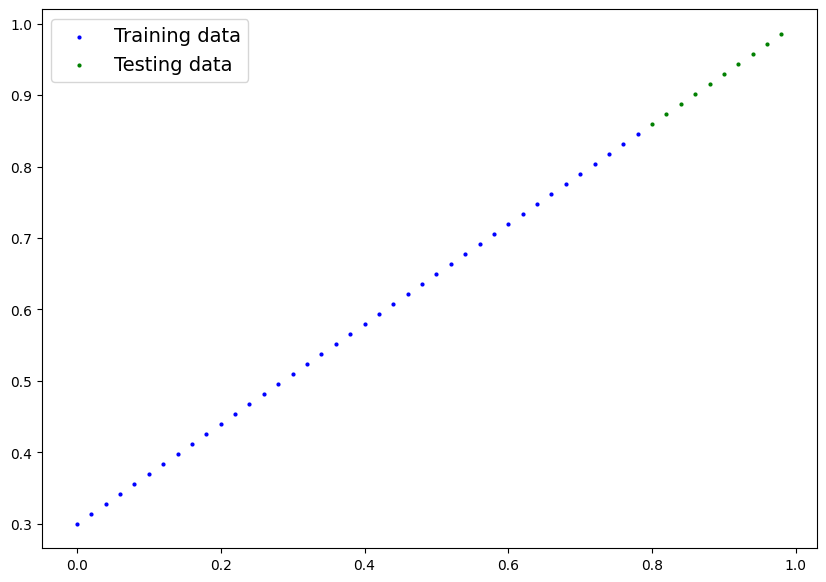

In [59]:
import matplotlib.pyplot as plt

def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14})
  
plot_predictions()

In [71]:
from torch import nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                dtype=torch.float),
                                    requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1,
                                             dtype=torch.float),
                                requires_grad=True)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias
    

In [72]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [73]:
with torch.inference_mode():
    y_preds = model_0(X_test)

In [74]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


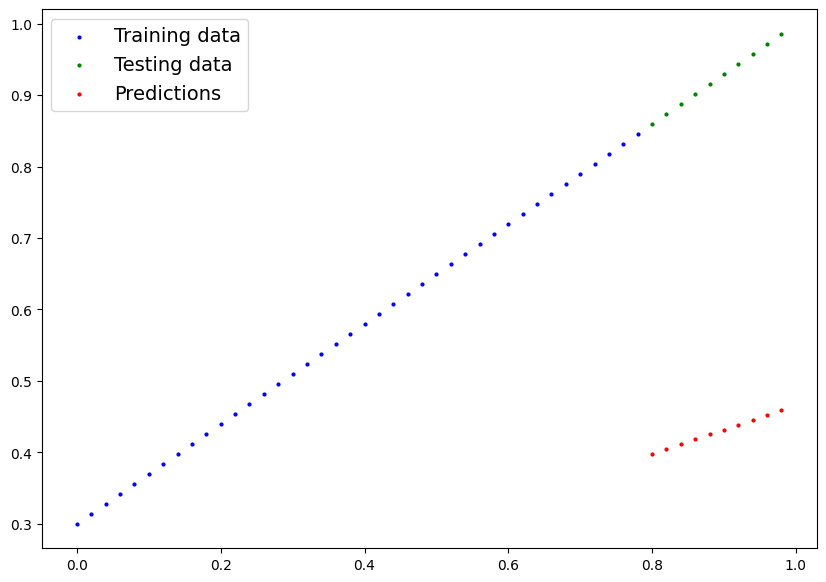

In [75]:
plot_predictions(predictions=y_preds)

In [76]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

In [77]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)


In [78]:
torch.manual_seed (42)

epochs = 100

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred, y_train)
    
    optimizer.zero_grad()

    loss.backward()
    
    optimizer.step()

    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(X_test)

        test_loss = loss_fn(test_pred, y_test.type(torch.float))

        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss}")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819


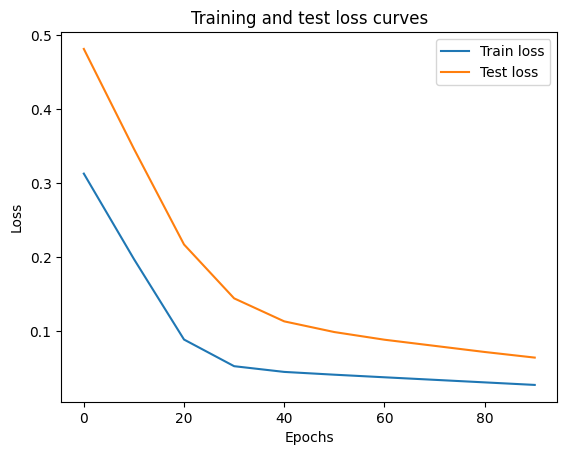

In [79]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [80]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.5784]), 'bias': tensor([0.3513])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


In [81]:
model_0.eval()

with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

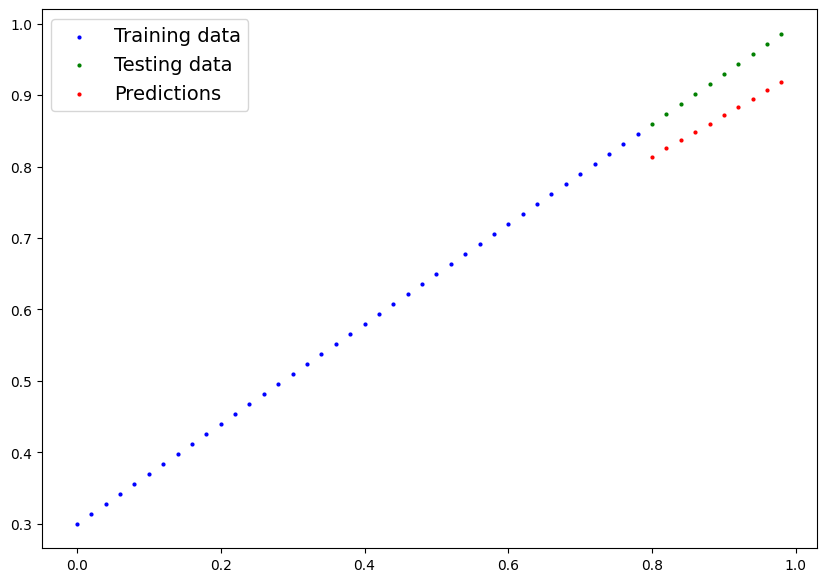

In [82]:
plot_predictions(predictions=y_preds)

In [83]:
from pathlib import Path

# 1. Create models directory 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path 
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH) 

Saving model to: models\01_pytorch_workflow_model_0.pth


In [84]:
# Instantiate a new instance of our model (this will be instantiated with random weights)
loaded_model_0 = LinearRegressionModel()

# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [85]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [111]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [112]:
train_split = int(0.8 * len(X))
X_train, y_train = X[train_split:], y[train_split:]
X_test, y_test = X[:train_split], y[:train_split]

len(X_train), len(y_train), len(X_test), len(y_test)

(10, 10, 40, 40)

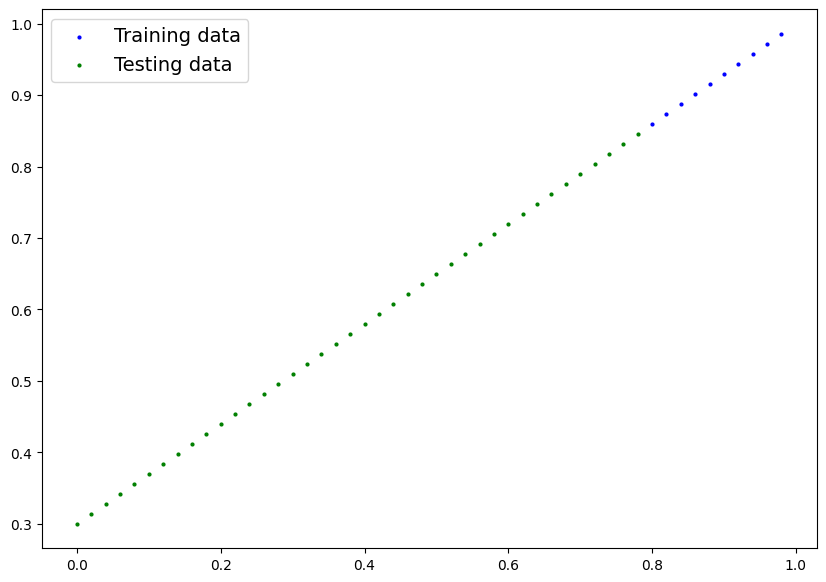

In [113]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

In [122]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1, 
                                      out_features=1)
    
    # Define the forward computation (input data x flows through nn.Linear())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# Set the manual seed when creating the model (this isn't always needed but is used for demonstrative purposes, try commenting it out and seeing what happens)
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [123]:
next(model_1.parameters()).device

device(type='cpu')

In [124]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

In [125]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr = 0.01)

In [130]:
torch.manual_seed(42)

# Set the number of epochs 
epochs = 1000 

# Put data on the available device
# Without this, error will happen (not all model/data on device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_1.train() # train mode is on by default after construction

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval() # put the model in evaluation mode for testing (inference)
    # 1. Forward pass
    with torch.inference_mode():
        test_pred = model_1(X_test)
    
        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.008192134089767933 | Test loss: 0.03506714105606079
Epoch: 100 | Train loss: 0.008192134089767933 | Test loss: 0.03506714105606079
Epoch: 200 | Train loss: 0.008192134089767933 | Test loss: 0.03506714105606079
Epoch: 300 | Train loss: 0.008192134089767933 | Test loss: 0.03506714105606079
Epoch: 400 | Train loss: 0.008192134089767933 | Test loss: 0.03506714105606079
Epoch: 500 | Train loss: 0.008192134089767933 | Test loss: 0.03506714105606079
Epoch: 600 | Train loss: 0.008192134089767933 | Test loss: 0.03506714105606079
Epoch: 700 | Train loss: 0.008192134089767933 | Test loss: 0.03506714105606079
Epoch: 800 | Train loss: 0.008192134089767933 | Test loss: 0.03506714105606079
Epoch: 900 | Train loss: 0.008192134089767933 | Test loss: 0.03506714105606079


In [131]:
# Find our model's learned parameters
from pprint import pprint # pprint = pretty print, see: https://docs.python.org/3/library/pprint.html 
print("The model learned the following values for weights and bias:")
pprint(model_1.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict([('linear_layer.weight', tensor([[0.6193]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3800], device='cuda:0'))])

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


In [134]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.3800],
        [0.3924],
        [0.4048],
        [0.4172],
        [0.4296],
        [0.4419],
        [0.4543],
        [0.4667],
        [0.4791],
        [0.4915],
        [0.5039],
        [0.5163],
        [0.5286],
        [0.5410],
        [0.5534],
        [0.5658],
        [0.5782],
        [0.5906],
        [0.6030],
        [0.6153],
        [0.6277],
        [0.6401],
        [0.6525],
        [0.6649],
        [0.6773],
        [0.6897],
        [0.7020],
        [0.7144],
        [0.7268],
        [0.7392],
        [0.7516],
        [0.7640],
        [0.7764],
        [0.7888],
        [0.8011],
        [0.8135],
        [0.8259],
        [0.8383],
        [0.8507],
        [0.8631]], device='cuda:0')

ValueError: x and y must be the same size

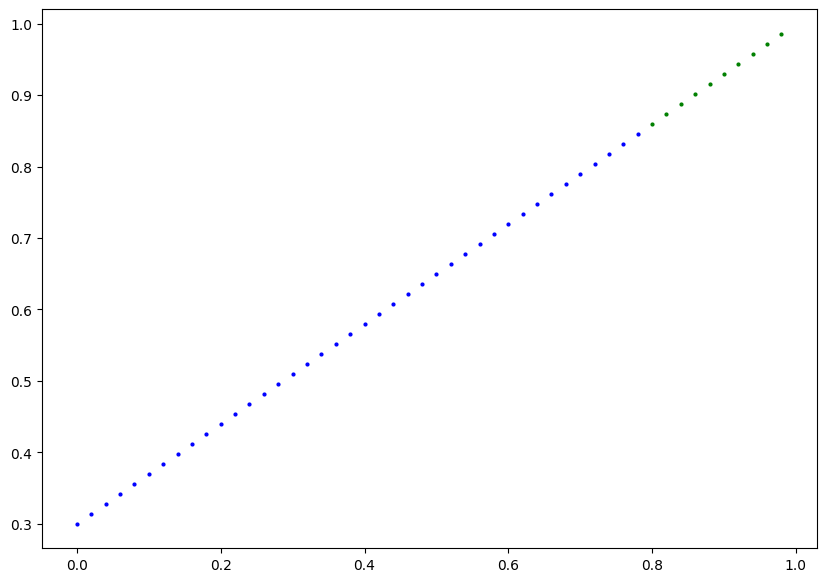

In [136]:
# plot_predictions(predictions=y_preds) # -> won't work... data not on CPU

# Put data on the CPU and plot it
plot_predictions(predictions=y_preds.cpu())